# LeetCode #153: Find Minimum in Rotated Sorted Array

https://leetcode.com/problems/find-minimum-in-rotated-sorted-array/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (linear scan)** | $O(n)$ | $O(1)$ |
| **Optimal: Binary Search on Rotation Pivot ★** | $O(\log n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (linear scan)
Scan every element tracking the minimum. Always $O(n)$; ignores the sorted structure entirely.

### Optimal: Binary Search on Rotation Pivot ★
The minimum is always at the rotation pivot. If `nums[mid] > nums[hi]`, the pivot (and therefore the minimum) is in the right half — so set `lo = mid + 1`. Otherwise the minimum is at mid or to the left — set `hi = mid`. Loop until `lo == hi`, which points at the minimum.

**Constraints:**
* n == nums.length
* 1 <= n <= 5000
* -5000 <= nums[i] <= 5000
* All values of nums are unique
* nums is sorted and rotated between 1 and n times


## Solutions

### C#

In [ ]:
public int FindMin(int[] nums) {
    int lo = 0, hi = nums.Length - 1;
    while (lo < hi) {
        int mid = lo + (hi - lo) / 2;
        // If mid is in the left (unsorted from right's perspective), minimum is right of mid
        if (nums[mid] > nums[hi]) lo = mid + 1;
        else hi = mid;  // Minimum is at mid or to its left
    }
    return nums[lo];
}


### Python

In [ ]:
def findMin(self, nums: list[int]) -> int:
    lo, hi = 0, len(nums) - 1
    while lo < hi:
        mid = lo + (hi - lo) // 2
        # If mid is in the left (unsorted from right's perspective), minimum is right of mid
        if nums[mid] > nums[hi]:
            lo = mid + 1
        else:
            hi = mid  # Minimum is at mid or to its left
    return nums[lo]


### Go

In [ ]:
func findMin(nums []int) int {
    lo, hi := 0, len(nums)-1
    for lo < hi {
        mid := lo + (hi-lo)/2
        // If mid is in the left (unsorted from right's perspective), minimum is right of mid
        if nums[mid] > nums[hi] {
            lo = mid + 1
        } else {
            hi = mid  // Minimum is at mid or to its left
        }
    }
    return nums[lo]
}


### Rust

In [ ]:
pub fn find_min(nums: Vec<i32>) -> i32 {
    let (mut lo, mut hi) = (0usize, nums.len() - 1);
    while lo < hi {
        let mid = lo + (hi - lo) / 2;
        // If mid is in the left (unsorted from right's perspective), minimum is right of mid
        if nums[mid] > nums[hi] {
            lo = mid + 1;
        } else {
            hi = mid;  // Minimum is at mid or to its left
        }
    }
    nums[lo]
}


## Example Scenarios

**1. Common Case**
**Input:** nums = [3, 4, 5, 1, 2]
lo=0,hi=4. mid=2(5)>nums[hi]=2 → lo=3. mid=3(1)≤1→ hi=3. lo=hi=3 → return nums[3]=1.

**2. Slightly Complex**
**Input:** nums = [4, 5, 6, 7, 0, 1, 2]
mid=3(7)>nums[hi]=2 → lo=4. mid=5(1)≤2 → hi=5. mid=4(0)≤1 → hi=4. lo=hi=4 → return 0.

**3. Edge Case: Time Factor**
**Input:** nums = [2, 3, 4, ..., 5000, 1] (rotated once at end)
The minimum (1) is at the last index. Each iteration eliminates the left half (nums[mid]>nums[hi]) until lo=4999, hi=4999. Depth: $\lceil \log_2 5000 \rceil = 13$ steps.

**4. Edge Case: Space Factor**
**Input:** nums = [1]
No rotation: lo=hi=0, loop never enters. Return nums[0]=1. Uses $O(1)$ space — exactly two pointers (lo, hi, mid).

**5. Almost-Impossible but Plausible**
**Input:** nums = [-5000, -4999, ..., 4999, 5000] (not rotated at all)
Every mid satisfies nums[mid] ≤ nums[hi] → hi=mid each iteration. Loop converges to lo=hi=0 and returns -5000. Algorithm handles zero-rotation correctly — the minimum stays at index 0.


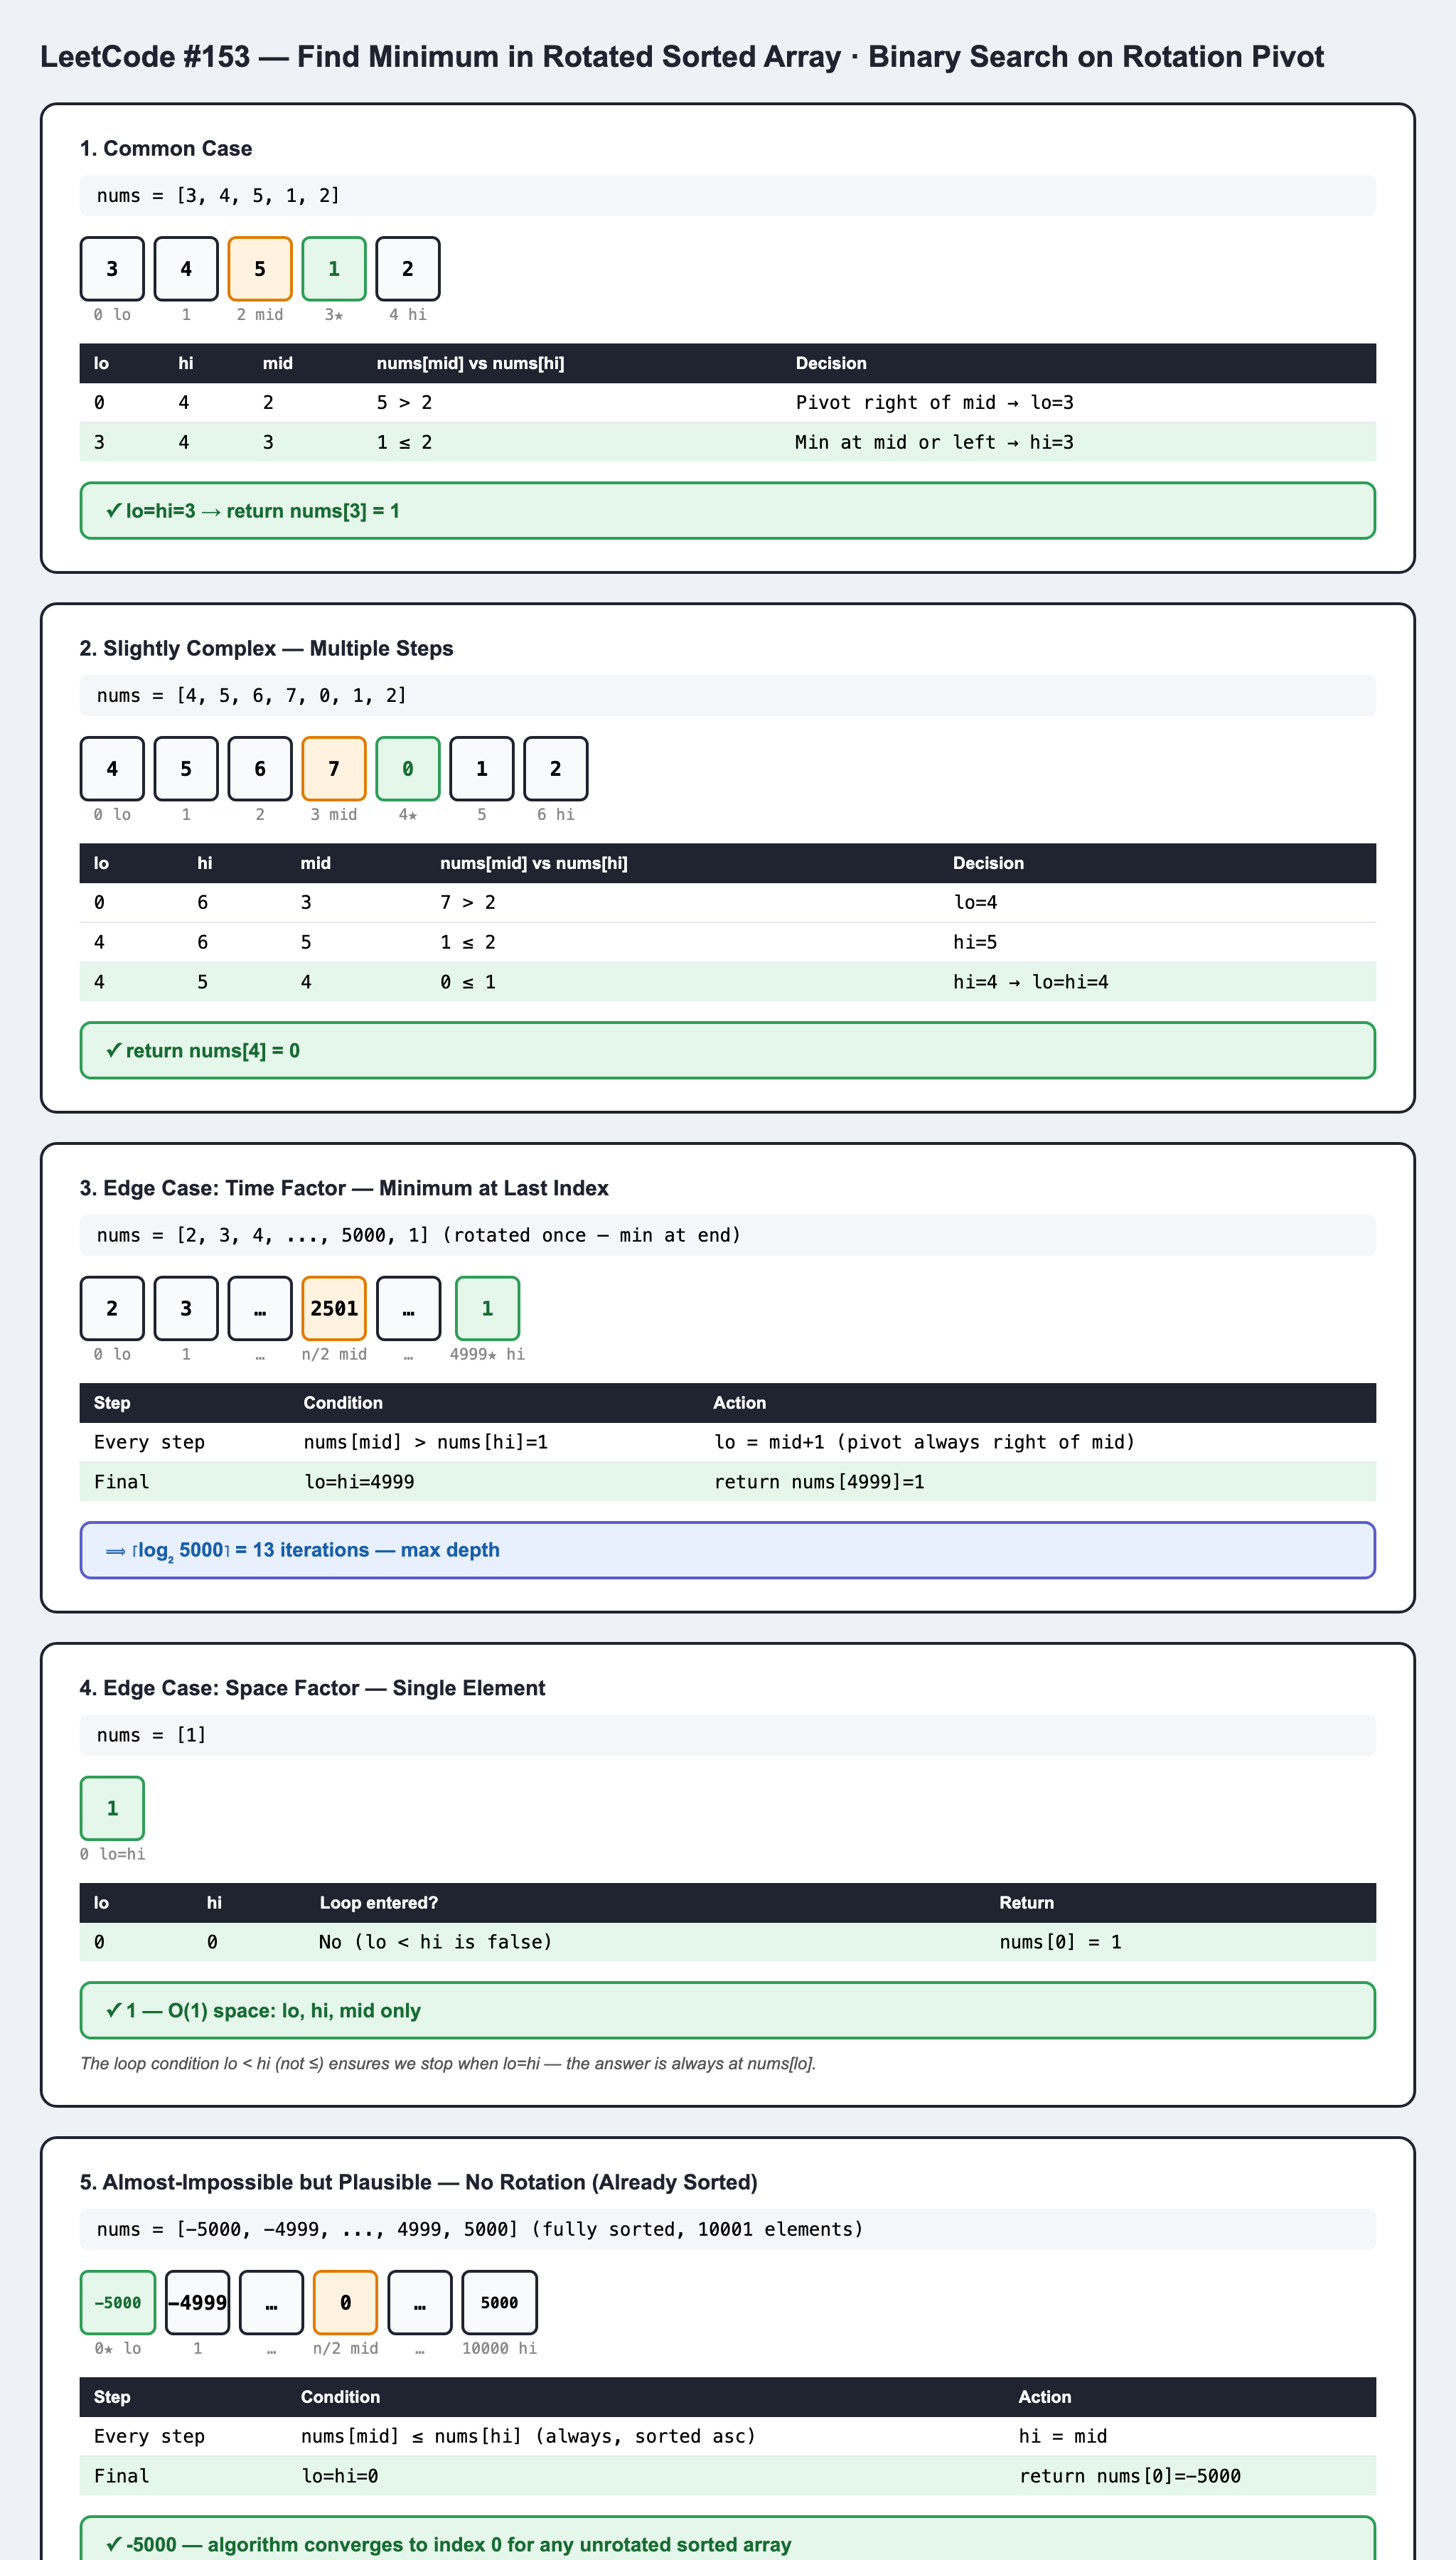